In [97]:
from decimal import Decimal, getcontext
import math

getcontext().prec = 50

#1 Ядро

class Vec:
    def __init__(self, x, y):
        self.x = Decimal(x)
        self.y = Decimal(y)

    def __add__(self, other):
        return Vec(self.x + other.x, self.y + other.y)

    def __sub__(self, other):
        return Vec(self.x - other.x, self.y - other.y)

    def __mul__(self, scalar):
        s = Decimal(scalar)
        return Vec(self.x * s, self.y * s)

    def __truediv__(self, scalar):
        s = Decimal(scalar)
        return Vec(self.x / s, self.y / s)

    def mag_sq(self):
        return self.x**2 + self.y**2

    def mag(self):
        return (self.x**2 + self.y**2).sqrt()

    def dist(self, other):
        return ((self.x - other.x)**2 + (self.y - other.y)**2).sqrt()

    def to_list(self): #для matplotlib
        return [float(self.x), float(self.y)]

    def __repr__(self):
        return f"Vec({self.x:.4e}, {self.y:.4e})"


class HighPrecisionBody:
    def __init__(self, name, mass, pos_x, pos_y, vel_x, vel_y):
        self.name = name
        self.mass = Decimal(mass)
        self.pos = Vec(pos_x, pos_y)
        self.vel = Vec(vel_x, vel_y)
        self.acc = Vec(0, 0)

    def update_position(self, dt):
        self.pos += self.vel * dt

    def update_velocity(self, dt):
        self.vel += self.acc * dt


class NBodySystem:
    def __init__(self, bodies: list[HighPrecisionBody]):
        self.bodies = bodies
        self.G = Decimal('6.67430e-11')

    def compute_accelerations(self):
        for i, body_a in enumerate(self.bodies):
            total_acc = Vec(0, 0)
            for j, body_b in enumerate(self.bodies):
                if i == j: continue
                r_vec = body_b.pos - body_a.pos
                distance = r_vec.mag()

                # Проверка: если расстояние NaN или слишком мало — пропускаем взаимодействие
                if distance.is_nan() or distance < Decimal('1e-5'):
                    continue

                force_mag = (self.G * body_b.mass) / (distance**3)
                total_acc += r_vec * force_mag
            body_a.acc = total_acc

    def get_kinetic_energy(self) -> Decimal:
        ke = Decimal(0)
        for body in self.bodies:
            ke += Decimal('0.5') * body.mass * body.vel.mag_sq()
        return ke

    def get_potential_energy(self) -> Decimal:
        pe = Decimal(0)
        n = len(self.bodies)
        for i in range(n):
            for j in range(i + 1, n):
                b1 = self.bodies[i]
                b2 = self.bodies[j]
                dist = b1.pos.dist(b2.pos)

                if dist.is_nan() or dist < Decimal('1e-5'):
                    dist = Decimal('1e6')

                pe -= (self.G * b1.mass * b2.mass) / dist
        return pe

    def get_total_energy(self) -> Decimal:
        return self.get_kinetic_energy() + self.get_potential_energy()

    def get_system_momentum(self) -> Vec:
        total_p = Vec(0, 0)
        for body in self.bodies:
            total_p += body.vel * body.mass
        return total_p

    def get_center_of_mass(self) -> Vec:
        total_mass = sum(b.mass for b in self.bodies)
        weighted_pos = Vec(0, 0)
        for body in self.bodies:
            weighted_pos += body.pos * body.mass
        return weighted_pos / total_mass

    def __repr__(self):
        e = self.get_total_energy()
        return f"NBodySystem(Bodies: {len(self.bodies)}, Energy: {e:.10e})"

if __name__ == "__main__":
    # Солнце и Земля
    sun = HighPrecisionBody("Sun", "1.989e30", 0, 0, 0, 0)
    earth = HighPrecisionBody("Earth", "5.972e24", "1.496e11", 0, 0, "29780")

    system = NBodySystem([sun, earth])
    system.compute_accelerations()

    print(f"Energy: {system.get_total_energy()}")
    print(f"Sun Accel: {sun.acc}")
    print(f"Earth Accel: {earth.acc}")

Energy: -2651295215327272727272727272727272.7272727272727273
Sun Accel: Vec(1.7810e-8, 0.0000e-64)
Earth Accel: Vec(-5.9317e-3, 0.0000e-59)


In [98]:
class Integrator:

    @staticmethod
    def get_state(system):
        return [(body.pos, body.vel) for body in system.bodies]

    @staticmethod
    def set_state(system, state):
        for i, (pos, vel) in enumerate(state):
            system.bodies[i].pos = pos
            system.bodies[i].vel = vel

    @staticmethod
    def rk4_step(system, dt):
        dt = Decimal(dt)
        half_dt = dt / Decimal(2)
        initial_state = Integrator.get_state(system)

        # k1
        system.compute_accelerations()
        k1_v = [body.acc for body in system.bodies]
        k1_pos = [body.vel for body in system.bodies]

        # k2
        for i, body in enumerate(system.bodies):
            body.pos = initial_state[i][0] + k1_pos[i] * half_dt
            body.vel = initial_state[i][1] + k1_v[i] * half_dt
        system.compute_accelerations()
        k2_v = [body.acc for body in system.bodies]
        k2_pos = [body.vel for body in system.bodies]

        # k3
        for i, body in enumerate(system.bodies):
            body.pos = initial_state[i][0] + k2_pos[i] * half_dt
            body.vel = initial_state[i][1] + k2_v[i] * half_dt
        system.compute_accelerations()
        k3_v = [body.acc for body in system.bodies]
        k3_pos = [body.vel for body in system.bodies]

        # k4
        for i, body in enumerate(system.bodies):
            body.pos = initial_state[i][0] + k3_pos[i] * dt
            body.vel = initial_state[i][1] + k3_v[i] * dt
        system.compute_accelerations()
        k4_v = [body.acc for body in system.bodies]
        k4_pos = [body.vel for body in system.bodies]

        # x(t+dt) = x(t) + (dt/6) * (k1 + 2k2 + 2k3 + k4)
        for i, body in enumerate(system.bodies):
            v_final = (k1_v[i] + k2_v[i] * 2 + k3_v[i] * 2 + k4_v[i]) / Decimal(6)
            pos_final = (k1_pos[i] + k2_pos[i] * 2 + k3_pos[i] * 2 + k4_pos[i]) / Decimal(6)

            body.pos = initial_state[i][0] + pos_final * dt
            body.vel = initial_state[i][1] + v_final * dt

if __name__ == "__main__":
    sun = HighPrecisionBody(
        name="Sun",
        mass="1.989e30",
        pos_x=0, pos_y=0,
        vel_x=0, vel_y=0
    )

    earth = HighPrecisionBody(
        name="Earth",
        mass="5.972e24",
        pos_x="1.496e11", pos_y=0,
        vel_x=0, vel_y="29780"
    )
    system = NBodySystem([sun, earth])

    initial_energy = system.get_total_energy()
    initial_pos = earth.pos.x

    print(f"Начальная позиция Земли: {earth.pos}")
    print(f"Начальная энергия системы: {initial_energy:.20f}")
    print("-" * 50)

    dt = 86400
    num_days = 10

    for day in range(1, num_days + 1):
        Integrator.rk4_step(system, dt)

        current_energy = system.get_total_energy()
        energy_loss = current_energy - initial_energy


    final_energy = system.get_total_energy()
    total_error = abs(final_energy - initial_energy)

    print("-" * 50)
    print(f"После {num_days} дней:")
    print(f"Суммарный дрейф энергии: {total_error:.2e}")


Начальная позиция Земли: Vec(1.4960e+11, 0.0000e+4)
Начальная энергия системы: -2651295215327272727272727272727272.72727272727272730000
--------------------------------------------------
--------------------------------------------------
После 10 дней:
Суммарный дрейф энергии: 1.90e+22


In [99]:
import torch
import torch.nn as nn
import torch.optim as optim

# 3 (PINN)

class PhysicsInformedNN(nn.Module):
    def __init__(self, num_bodies=3):
        super().__init__()
        self.num_bodies = num_bodies
        input_dim = num_bodies * 4
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.Tanh(),
            nn.Linear(256, 256),
            nn.Tanh(),
            nn.Linear(256, input_dim)
        ).double()

    def forward(self, x):
        return self.net(x.double())

    def calculate_energy_torch(self, state, masses, G):
        batch_size = state.shape[0]
        positions = state[:, :self.num_bodies*2].view(batch_size, self.num_bodies, 2)
        velocities = state[:, self.num_bodies*2:].view(batch_size, self.num_bodies, 2)

        ke = torch.zeros(batch_size, dtype=torch.float64)
        for i in range(self.num_bodies):
            ke += 0.5 * masses[i] * torch.sum(velocities[:, i, :]**2, dim=1)

        pe = torch.zeros(batch_size, dtype=torch.float64)
        for i in range(self.num_bodies):
            for j in range(i + 1, self.num_bodies):
                r_vec = positions[:, j, :] - positions[:, i, :]
                dist = torch.sqrt(torch.sum(r_vec**2, dim=1) + 1e-9)
                pe -= (G * masses[i] * masses[j]) / dist
        return ke + pe

class NeuralStabilizer:
    def __init__(self, system, G):
        self.system = system
        self.num_bodies = len(system.bodies)
        self.model = PhysicsInformedNN(num_bodies=self.num_bodies)
        self.optimizer = optim.Adam(self.model.parameters(), lr=1e-4)
        self.G = float(G)
        self.masses = torch.tensor([float(b.mass) for b in system.bodies], dtype=torch.float64)

        initial_e = float(system.get_total_energy())
        self.target_energy = initial_e
        self.energy_scale = abs(initial_e) if initial_e != 0 else 1e30

        self.pos_scale = 1.5e11
        self.vel_scale = 30000.0

    def _get_current_state_tensor(self):
        flat_state = []
        for b in self.system.bodies:
            flat_state.extend([float(b.pos.x)/self.pos_scale, float(b.pos.y)/self.pos_scale])
        for b in self.system.bodies:
            flat_state.extend([float(b.vel.x)/self.vel_scale, float(b.vel.y)/self.vel_scale])
        return torch.tensor([flat_state], dtype=torch.float64)

    def apply_correction(self):
        self.model.train()
        epsilon = 1e-4

        state_tensor = self._get_current_state_tensor()
        if torch.isnan(state_tensor).any(): return 0.0

        state_tensor.requires_grad = True
        correction = self.model(state_tensor)

        corrected_state = state_tensor + correction * epsilon

        # Пересчет для физики
        s_phys = corrected_state.clone()
        s_phys[:, :self.num_bodies*2] *= self.pos_scale
        s_phys[:, self.num_bodies*2:] *= self.vel_scale

        e_after = self.model.calculate_energy_torch(s_phys, self.masses, self.G)

        loss = torch.abs((e_after - self.target_energy) / self.energy_scale).mean()

        if torch.isnan(loss):
            self.optimizer.zero_grad()
            return 0.0

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 0.5)
        self.optimizer.step()

        with torch.no_grad():
            new_vals = s_phys[0].cpu().numpy()
            if np.isnan(new_vals).any(): return float(loss)

            for i, b in enumerate(self.system.bodies):
                b.pos.x = Decimal(float(new_vals[i*2]))
                b.pos.y = Decimal(float(new_vals[i*2+1]))
                v_idx = self.num_bodies*2 + i*2
                b.vel.x = Decimal(float(new_vals[v_idx]))
                b.vel.y = Decimal(float(new_vals[v_idx+1]))

        return float(loss)

In [100]:
import time

# 4 КОНТРОЛЛЕР

class HybridSimulation:
    def __init__(self, system, dt, use_pinn=True):
        self.system = system
        self.dt = Decimal(dt)
        self.use_pinn = use_pinn

        self.G = system.G
        self.stabilizer = NeuralStabilizer(system, self.G)

        self.history = {
            'time': [],
            'energy': [],
            'energy_error': [],
            'positions': [[] for _ in range(len(system.bodies))],
            'pinn_loss': []
        }

        self.initial_energy = float(system.get_total_energy())
        self.start_time = time.time()

    def step(self, current_step_idx):

        # 1. RK4
        Integrator.rk4_step(self.system, self.dt)

        # 2. Нейросетевая коррекция
        loss = 0
        if self.use_pinn:
            loss = self.stabilizer.apply_correction()

        # 3. Запись
        current_e = float(self.system.get_total_energy())
        self.history['time'].append(current_step_idx * float(self.dt))
        self.history['energy'].append(current_e)
        self.history['energy_error'].append(abs(current_e - self.initial_energy))
        self.history['pinn_loss'].append(loss)

        for i, body in enumerate(self.system.bodies):
            self.history['positions'][i].append((float(body.pos.x), float(body.pos.y)))

    def run(self, num_steps):
        print(f"Target Steps: {num_steps} | Initial Energy: {self.initial_energy:.6f}")

        for i in range(num_steps):
            self.step(i)

            if i % 100 == 0:
                err = self.history['energy_error'][-1]
                print(f"Step {i}/{num_steps} | Energy Error: {err:.2e}")

        return self.history

# =============================================================================
# ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ДЛЯ ПОДГОТОВКИ СЦЕНАРИЕВ
# =============================================================================

def create_stable_orbit_scenario():
    sun = HighPrecisionBody("Sun", "1.989e30", 0, 0, 0, 0)
    earth = HighPrecisionBody("Earth", "5.972e24", "1.496e11", 0, 0, "29780")
    return NBodySystem([sun, earth])

def create_three_body_chaos():
    m = "1e30"
    G = Decimal('6.67430e-11')
    p1 = ("0.97000436", "-0.24308753")
    v1 = ("0.46620368", "0.43236573")
    b1 = HighPrecisionBody("Body 1", m, "-1e11", 0, 0, "10000")
    b2 = HighPrecisionBody("Body 2", m, "1e11", 0, 0, "-10000")
    b3 = HighPrecisionBody("Body 3", m, 0, 0, "5000", "5000")
    return NBodySystem([b1, b2, b3])


[1/2] Классический RK4 (dt=3600)
Target Steps: 10000 | Initial Energy: -2651295215327272852111446142615552.000000
Step 0/10000 | Energy Error: 0.00e+00
Step 100/10000 | Energy Error: 0.00e+00
Step 200/10000 | Energy Error: 0.00e+00
Step 300/10000 | Energy Error: 0.00e+00
Step 400/10000 | Energy Error: 0.00e+00
Step 500/10000 | Energy Error: 0.00e+00
Step 600/10000 | Energy Error: 0.00e+00
Step 700/10000 | Energy Error: 0.00e+00
Step 800/10000 | Energy Error: 0.00e+00
Step 900/10000 | Energy Error: 0.00e+00
Step 1000/10000 | Energy Error: 0.00e+00
Step 1100/10000 | Energy Error: 0.00e+00
Step 1200/10000 | Energy Error: 0.00e+00
Step 1300/10000 | Energy Error: 0.00e+00
Step 1400/10000 | Energy Error: 0.00e+00
Step 1500/10000 | Energy Error: 0.00e+00
Step 1600/10000 | Energy Error: 0.00e+00
Step 1700/10000 | Energy Error: 0.00e+00
Step 1800/10000 | Energy Error: 0.00e+00
Step 1900/10000 | Energy Error: 0.00e+00
Step 2000/10000 | Energy Error: 0.00e+00
Step 2100/10000 | Energy Error: 0.00

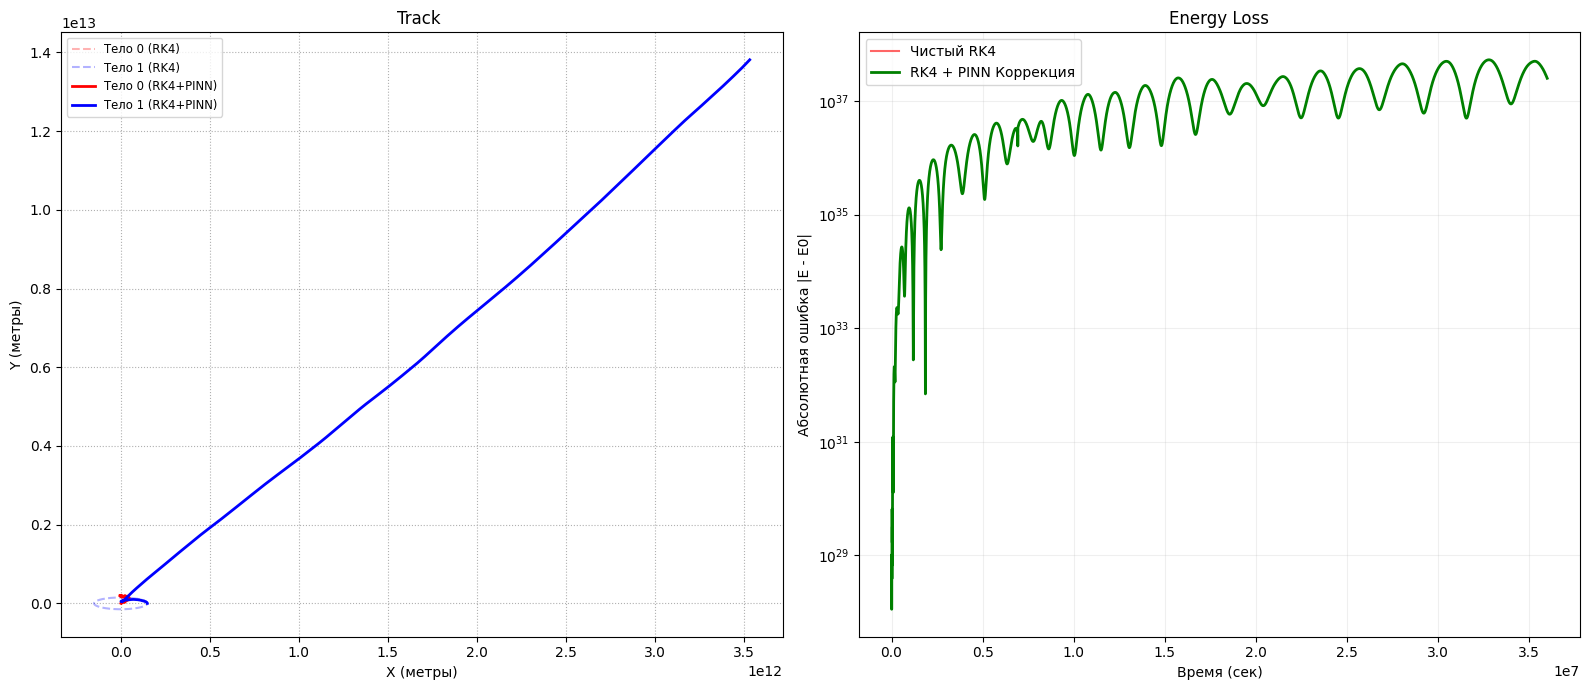

In [103]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
class Visualizer:
    @staticmethod
    def plot_results(history_no_pinn, history_with_pinn):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

        ax1.set_title("Track ")
        colors = ['red', 'blue', 'green', 'orange', 'purple']

        # БЕЗ нейросети (пунктиром)
        for i, pos_list in enumerate(history_no_pinn['positions']):
            pos_array = np.array(pos_list)
            ax1.plot(pos_array[:, 0], pos_array[:, 1], '--', color=colors[i % 5],
                     alpha=0.3, label=f"Тело {i} (RK4)")

        # С нейронкой (сплошной линией)
        for i, pos_list in enumerate(history_with_pinn['positions']):
            pos_array = np.array(pos_list)
            ax1.plot(pos_array[:, 0], pos_array[:, 1], '-', color=colors[i % 5],
                     linewidth=2, label=f"Тело {i} (RK4+PINN)")

        ax1.set_xlabel("X (метры)")
        ax1.set_ylabel("Y (метры)")
        ax1.legend(fontsize='small')
        ax1.grid(True, linestyle=':')


        ax2.set_title("Energy Loss")
        ax2.plot(history_no_pinn['time'], history_no_pinn['energy_error'],
                 label="Чистый RK4", color='red', alpha=0.6)
        ax2.plot(history_with_pinn['time'], history_with_pinn['energy_error'],
                 label="RK4 + PINN Коррекция", color='green', linewidth=2)

        ax2.set_yscale('log')
        ax2.set_xlabel("Время (сек)")
        ax2.set_ylabel("Абсолютная ошибка |E - E0|")
        ax2.legend()
        ax2.grid(True, which="both", ls="-", alpha=0.2)

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":

    TIME_STEP = 3600
    TOTAL_STEPS = 10000

    m_star = "2e30"

    def get_setup():
        sun = HighPrecisionBody("Sun", "1.989e30", 0, 0, 0, 0)
        earth = HighPrecisionBody("Earth", "5.972e24", "1.496e11", 0, 0, "29780")
        return NBodySystem([sun, earth])

    # 1. Прогон классики
    print(f"\n[1/2] Классический RK4 (dt={TIME_STEP})")
    system_math = get_setup()
    sim_math = HybridSimulation(system_math, dt=TIME_STEP, use_pinn=False)
    history_math = sim_math.run(num_steps=TOTAL_STEPS)

    # 2. Прогон гибрида
    print(f"\n[2/2] Гибридный RK4 + PINN (dt={TIME_STEP})")
    system_hybrid = get_setup()
    sim_hybrid = HybridSimulation(system_hybrid, dt=TIME_STEP, use_pinn=True)
    history_hybrid = sim_hybrid.run(num_steps=TOTAL_STEPS)

    viz = Visualizer()
    viz.plot_results(history_math, history_hybrid)